# Reconnaissance du genre des auteur.trice

In [1]:
#%pip install matplotlib
#%pip install seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression

## 1. Chargement et exploration des données

In [2]:
df = pd.read_csv("5_char_for_novel.csv")

In [3]:
df.head()

,title,author_gender,Gender,type
0,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1.0,0,1
1,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1.0,1,1
2,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1.0,1,1
3,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1.0,1,1
4,1833_Girardin-Delphine-de_Contes-d-une-vieille...,1.0,1,2


In [4]:
df.shape

(614, 4)

## Quelque statistique

In [5]:
# affichage du nombre de personnages par catégorie
# 0 = male author, 1 = female author
df["author_gender"].value_counts()

author_gender
1.0    409
0.0    199
Name: count, dtype: int64

Sur 596 personnages (environ 5 pour livre), on trouve 409 personnages écrits par des femmes, et seulement 199 personnages écrits par des hommes!

In [6]:
# affichage du nombre de personnages par type
# 0 = adulte, 1 = enfant, 2 = animal, 3 = poupée, 4 = objet, 5 = autre
df["type"].value_counts()

type
0    281
1    279
5     31
2     19
3      3
4      1
Name: count, dtype: int64

In [32]:
import pandas as pd

# Carica il file
df = pd.read_csv("5_char_for_novel.csv")

# Filtra solo type 0 o 1
df= df[df["type"].isin([0, 1])]

In [33]:
def plot_author_gender_distribution(df):
    """
    Visualizza il numero di personaggi creati da autori uomini e autrici donne.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame contenente la colonna 'author_gender'
        (0 = male author, 1 = female author)
    """
    # Definiamo i colori: puoi usare nomi standard, hex code o RGB
    colors = [ "#c6bbb1", '#cfc688']
    
    counts = df["author_gender"].value_counts().sort_index()
    
    labels = ['Male author', 'Female author']
    
    plt.figure(figsize=(6, 4))
    plt.bar(labels, counts, color=colors)
    
    plt.xlabel('Genre auteur')
    plt.ylabel('Nombre des personnages')
    plt.title('Nombre des personnages pour genre des auteurs')
    
    plt.tight_layout()
    plt.show()


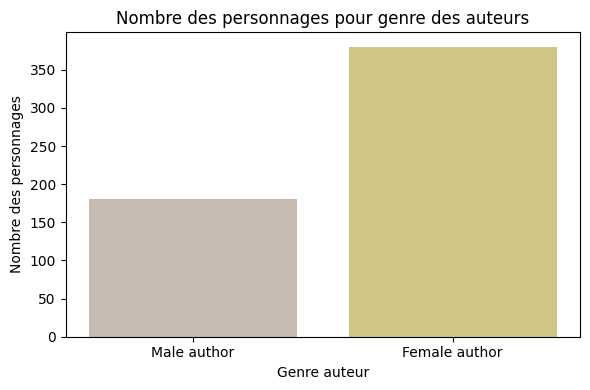

In [34]:
plot_author_gender_distribution(df)

### Genre de personnages pour genre de l'auteur/autrice

In [54]:
# Contingency table
df_named = df.copy()

df_named['author_gender'] = df_named['author_gender'].map({0: 'Auteurs', 1: 'Autrices'})
df_named['Gender'] = df_named['Gender'].map({0: 'Personnages masculins', 1: 'Personnages féminins'})

contingency = pd.crosstab(df_named['author_gender'], df_named['Gender'])


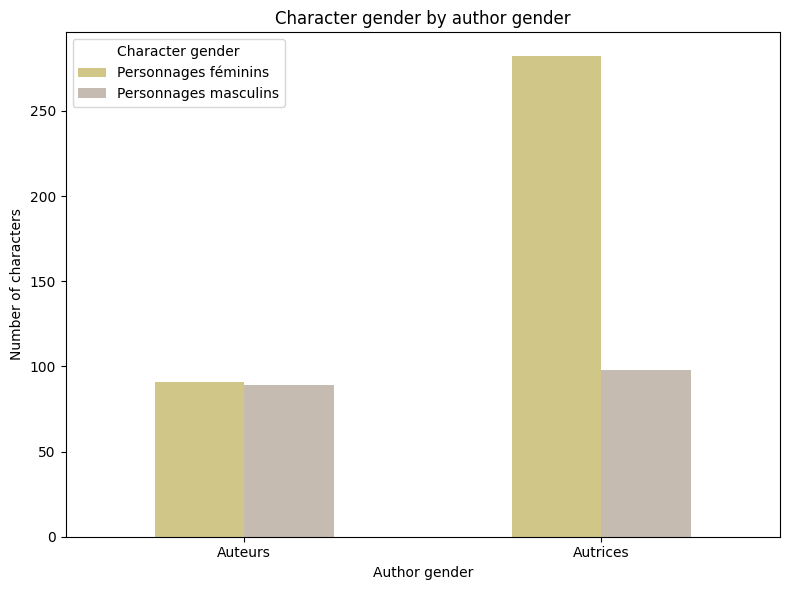

In [55]:
# Definiamo i colori: puoi usare nomi standard, hex code o RGB
colors = ['#cfc688', "#c6bbb1"]

# Plotting the contingency table
contingency.plot(
    kind='bar',
    figsize=(8, 6),
    color=colors
)

plt.xlabel('Author gender')
plt.ylabel('Number of characters')
plt.title('Character gender by author gender')
plt.xticks(rotation=0)
plt.legend(title='Character gender')
plt.tight_layout()
plt.show()


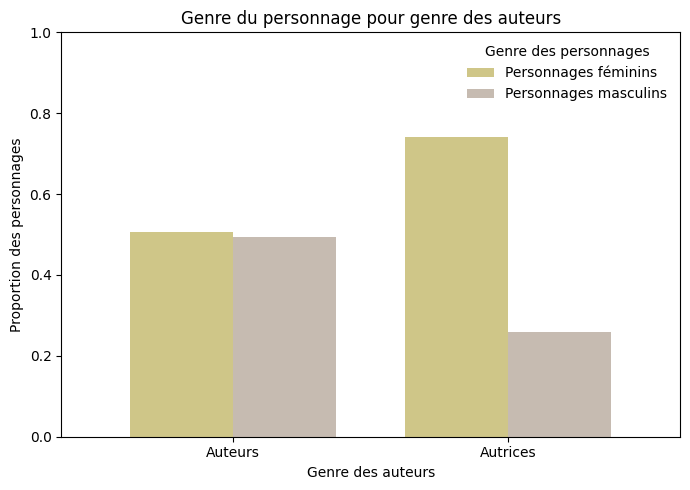

In [56]:
# affichage en pourcentage
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)

plt.figure(figsize=(7, 5))

contingency_pct.plot(
    kind='bar',
    width=0.75,
    ax=plt.gca(),
    color = colors
)

plt.xlabel('Genre des auteurs')
plt.ylabel('Proportion des personnages')
plt.title('Genre du personnage pour genre des auteurs')
plt.xticks(rotation=0)
plt.legend(title='Genre des personnages', frameon=False)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


### Exploration des relations

In [57]:
from scipy.stats import chi2_contingency

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic (χ²): {chi2:.4f}")
print(f"p-value: {p}")
print(f"Degrees of freedom (dof): {dof}")


Chi-square statistic (χ²): 29.6740
p-value: 5.111647348713268e-08
Degrees of freedom (dof): 1


In [52]:
contingency

array([[ 91, 189],
       [282,  98]])

In [47]:
# numero totale di osservazioni

# tabella di contingenza
contingency = np.array([
    [91, 189],
    [282, 98]
])
n = contingency.sum()

# coefficiente phi
phi = np.sqrt(chi2 / n)
print(f"Phi: {phi:.4f}")

Phi: 0.2120


In [39]:
# Affichage des fréquences attendues
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

print("\nExpected frequencies under independence:")
print(expected_df.round(2))




Expected frequencies under independence:
Gender         Personnages féminins  Personnages masculins
author_gender                                             
Auteurs                      119.89                  60.11
Autrices                     253.11                 126.89


### Quantité d'enfants par genre auteur

In [58]:
# analyse en ne gardant que les types adulte (0) et enfant (1)
df_enf = df[df["type"].isin([0, 1])]
df_enf["type"].value_counts()

type
0    281
1    279
Name: count, dtype: int64

In [59]:
df_named = df.copy()

df_named['author_gender'] = df_named['author_gender'].map({0: 'Auteurs', 1: 'Autrices'})
df_named['type'] = df_named['type'].map({0: 'Adulte', 1: 'Enfant'})

contingency_enf = pd.crosstab(df_named['author_gender'], df_named['type'])

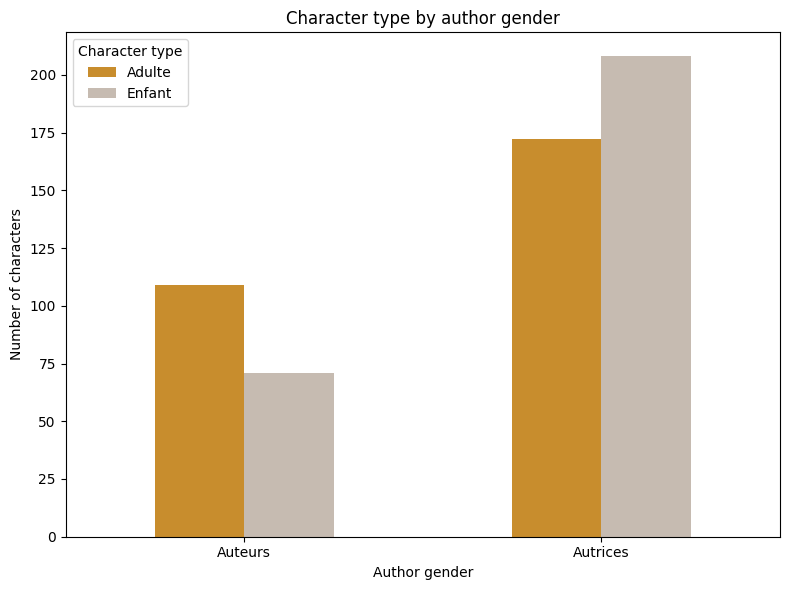

In [60]:
colors = ['#c88d2d', "#c6bbb1"]

contingency_enf.plot(
    kind='bar',
    figsize=(8, 6),
    color = colors
)

plt.xlabel('Author gender')
plt.ylabel('Number of characters')
plt.title('Character type by author gender')
plt.xticks(rotation=0)
plt.legend(title='Character type')
plt.tight_layout()
plt.show()


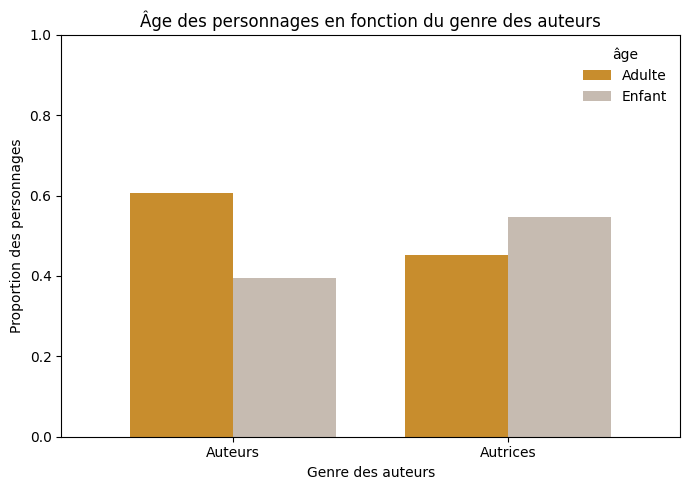

In [61]:
# affichage en pourcentage
contingency_pct = contingency_enf.div(contingency_enf.sum(axis=1), axis=0)

colors = ['#c88d2d', "#c6bbb1"]

plt.figure(figsize=(7, 5))

contingency_pct.plot(
    kind='bar',
    width=0.75,
    ax=plt.gca(),
    color = colors
)

plt.xlabel('Genre des auteurs')
plt.ylabel('Proportion des personnages')
plt.title('Âge des personnages en fonction du genre des auteurs')
plt.xticks(rotation=0)
plt.legend(title='âge', frameon=False)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


In [62]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_enf)

print(f"Chi-square statistic (χ²): {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom (dof): {dof}")


Chi-square statistic (χ²): 10.8222
p-value: 0.0010
Degrees of freedom (dof): 1


In [64]:
contingency_enf

type,Adulte,Enfant
author_gender,,
Auteurs,109,71
Autrices,172,208


In [22]:
# Affichage des fréquences attendues
expected_df = pd.DataFrame(
    expected,
    index=contingency_enf.index,
    columns=contingency_enf.columns
)

print("\nExpected frequencies under independence:")
print(expected_df.round(2))




Expected frequencies under independence:
type           Adulte  Enfant
author_gender                
Auteur          90.32   89.68
Autrice        190.68  189.32


In [65]:
# numero totale di osservazioni

# tabella di contingenza
contingency = np.array([
    [109, 71],
    [172, 208]
])
n = contingency.sum()

# coefficiente phi
phi = np.sqrt(chi2 / n)
print(f"Phi: {phi:.4f}")

Phi: 0.1390
